In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact
from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit
import warnings

## Cargar la tabla de parámetros globales

In [26]:
df_global = pd.read_csv('./../data/processed/parametros_globales.csv', index_col='id')

## Función de densidad volumétrica de número (King)

In [27]:
def rho(r, rc, rt, k):
  values = np.zeros_like(r, dtype=float)

  mask = r < rt
  r_valid = r[mask]

  w = np.sqrt((1 + (r_valid/rc)**2) / (1 + (rt/rc)**2))

  C = k / (np.pi * rc * (1 + (rt/rc)**2)**1.5)

  term1 = 1.0 / (w**2)
  term2 = (1.0 / w) * np.arccos(w) - np.sqrt(1 - w**2)

  values[mask] = C * term1 * term2
  
  return values

In [28]:
def densidad_king_adimensional(r, rc, rt):
    """
    Calcula la forma de la densidad espacial de King (sin normalizar).
    Equivale a la ecuación 27 de King 1962, ignorando el factor k.
    """
    # Evitar evaluar radios mayores a rt
    r_val = np.clip(r, 0, rt * 0.99999)
    
    # Variable z del modelo de King
    z = np.sqrt((1 + (r_val/rc)**2) / (1 + (rt/rc)**2))
    
    # Ecuación de densidad
    n = (1.0 / z**2) * ((1.0 / z) * np.arccos(z) - np.sqrt(1 - z**2))
    
    # La densidad es estrictamente 0 más allá del radio de marea
    n[r >= rt] = 0.0
    return n

In [29]:
def modelo_sigma2(r_bins, A, rc, rt):
    """
    Evalúa la integral de Jeans para la dispersión de velocidades.
    r_bins: Radios donde tienes tus datos.
    A: Amplitud de la dispersión de velocidades (parámetro libre).
    rc: Radio del núcleo (parámetro libre).
    rt: Radio de marea (parámetro libre).
    """
    # 1. Crear una grilla densa desde el centro hasta el radio de marea
    # Usamos una grilla logarítmica/lineal mixta o simplemente lineal densa
    r_grid = np.linspace(1e-5, rt, 2000)
    
    # 2. Densidad en la grilla
    n_grid = densidad_king_adimensional(r_grid, rc, rt)
    
    # 3. Masa encerrada (acumulada) en la grilla
    # M(<r) ~ integral( r^2 * n(r) dr )
    integrando_M = r_grid**2 * n_grid
    M_grid = cumulative_trapezoid(integrando_M, r_grid, initial=0)
    
    # 4. Integral de Jeans: integral desde r hasta rt de (n * M / r^2)
    integrando_jeans = n_grid * M_grid / r_grid**2
    
    # Truco: integral_r_rt = integral_0_rt - integral_0_r
    integral_0_r = cumulative_trapezoid(integrando_jeans, r_grid, initial=0)
    integral_r_rt = integral_0_r[-1] - integral_0_r
    
    # 5. Dispersión de velocidades teórica en la grilla
    sigma2_grid = np.zeros_like(r_grid)
    mask = n_grid > 0
    sigma2_grid[mask] = A * integral_r_rt[mask] / n_grid[mask]
    
    # 6. Interpolar los resultados teóricos a los r_bins del usuario
    interpolador = interp1d(r_grid, sigma2_grid, kind='cubic', 
                            fill_value=0.0, bounds_error=False)
    
    return interpolador(r_bins)

In [30]:
def plot_cluster(cluster_id):
    # Extraer parámetros del cúmulo desde el archivo general
    datos_cumulo = df_global.loc[cluster_id]
    rc = datos_cumulo['rc']
    rt = datos_cumulo['rt']
    k = datos_cumulo['k']
    nombre = datos_cumulo['nombre']
    
    # Cargar los datos específicos de los bins del cúmulo
    file_path = f'./../data/processed/perfiles_radiales/cluster_{cluster_id}.csv'
        
    df_bins = pd.read_csv(file_path)
    r = df_bins['r_bin']

    # Ajuste del modelo de King a la densidad de número observada
    rho_num = df_bins['densidad_n']
    p0 = [rc, rt, k]  # Valores iniciales para
    bounds = ([0.1, 0.1, 0.1], [np.inf, np.inf, np.inf])  # rc > 0, rt > 0, k > 0
    popt, pcov = curve_fit(rho, r, rho_num, p0=p0, bounds=bounds)
    rc_rho_num, rt_rho_num, k_rho_num = popt

    print("Ajuste del modelo de King a la densidad de número observada:")
    print(f"rc ajustado: {rc_rho_num:.2f} (original: {rc:.2f})")
    print(f"rt ajustado: {rt_rho_num:.2f} (original: {rt:.2f})")
    print(f"k ajustado: {k_rho_num:.2f} (original: {k:.2f})")

    # Ajuste del modelo de King a la dispersión de velocidades observada
    sigma2_obs = df_bins['sigma_cuadrado']
    p0 = [np.max(sigma2_obs), rc, rt]  # Valores iniciales para A, rc, rt
    bounds = ([0, 0.1, 0.1], [np.inf, np.inf, np.inf])  # A > 0, rc > 0, rt > 0
    popt, pcov = curve_fit(modelo_sigma2, r, sigma2_obs, p0=p0, bounds=bounds)
    A_sig2, rc_sig2, rt_sig2 = popt

    print("\nAjuste del modelo de King a la dispersión de velocidades observada:")
    print(f"Ajuste A: {A_sig2:.2f}")
    print(f"rc ajustado: {rc_sig2:.2f} (original: {rc:.2f})")
    print(f"rt ajustado: {rt_sig2:.2f} (original: {rt:.2f})")
    
    # Crear figura con 3 subgráficos (1 fila, 3 columnas)
    fig, axs = plt.subplots(2, 2, figsize=(10, 10))
    fig.suptitle(f'Perfil del Cúmulo: {nombre} (ID: {cluster_id}) | $r_c={rc:.2f}, r_t={rt:.2f}, k={k:.2f}$', fontsize=16)

    # Gráfico 1: Densidad de Número vs Modelo de King
    axs[0, 0].plot(r, df_bins['densidad_n'], 'bo-', label='Observado')
    
    # Generar curva suave para el modelo de King
    r_teorico = np.linspace(min(r), rt_rho_num * 1.1, 100) # Graficar hasta el radio de marea
    axs[0, 0].plot(r_teorico, rho(r_teorico, rc_rho_num, rt_rho_num, k_rho_num), 'r--', label='Modelo King')
    
    axs[0, 0].set_xscale('log')
    axs[0, 0].set_yscale('log')
    axs[0, 0].set_xlabel('Radio (bin)')
    axs[0, 0].set_ylabel('Densidad de Número')
    axs[0, 0].axvline(rc_rho_num, color='gray', linestyle=':', label='$r_c$')
    axs[0, 0].axvline(rt_rho_num, color='orange', linestyle=':', label='$r_t$')
    axs[0, 0].legend()

    # Gráfico 2: Densidad Volumétrica de Masa
    axs[0, 1].plot(r, df_bins['densidad_vol'], 'go-')
    axs[0, 1].set_xscale('log')
    axs[0, 1].set_yscale('log')
    axs[0, 1].set_xlabel('Radio (bin)')
    axs[0, 1].set_ylabel('Densidad de Masa')

    # Gráfico 3: Dispersión de Velocidades
    axs[1, 0].plot(r, df_bins['sigma_cuadrado'], 'mo-', label='Observado')

    # Generar ajuste del modelo de King para la dispersión de velocidades
    r_plot = np.linspace(0.1, rt_sig2 * 1.1, 200)
    sigma2_plot = modelo_sigma2(r_plot, A_sig2, rc_sig2, rt_sig2)

    axs[1, 0].plot(r_plot, sigma2_plot, 'r--', label='Modelo Ajustado de King')
    axs[1, 0].axvline(rc_sig2, color='gray', linestyle=':', label='$r_c$')
    axs[1, 0].axvline(rt_sig2, color='orange', linestyle=':', label='$r_t$')
    axs[1, 0].set_xscale('log')
    axs[1, 0].set_xlabel('Radio (bin)')
    axs[1, 0].set_ylabel('Dispersión de Velocidades (km/s)')
    axs[1, 0].legend()

    # Gráfico 4: Masa Encerada
    axs[1, 1].plot(r, df_bins['mass_accum'], 'co-')
    axs[1, 1].set_xscale('log')
    axs[1, 1].set_yscale('log')
    axs[1, 1].set_xlabel('Radio (bin)')
    axs[1, 1].set_ylabel('Masa acumulada')


    plt.tight_layout()
    plt.show()

Ajuste del modelo de King a la densidad de número observada:
rc ajustado: 4.31 (original: 3.71)
rt ajustado: 27.72 (original: 33.00)
k ajustado: 49.39 (original: 53.89)

Ajuste del modelo de King a la dispersión de velocidades observada:
Ajuste A: 0.00
rc ajustado: 3.53 (original: 3.71)
rt ajustado: 30.19 (original: 33.00)


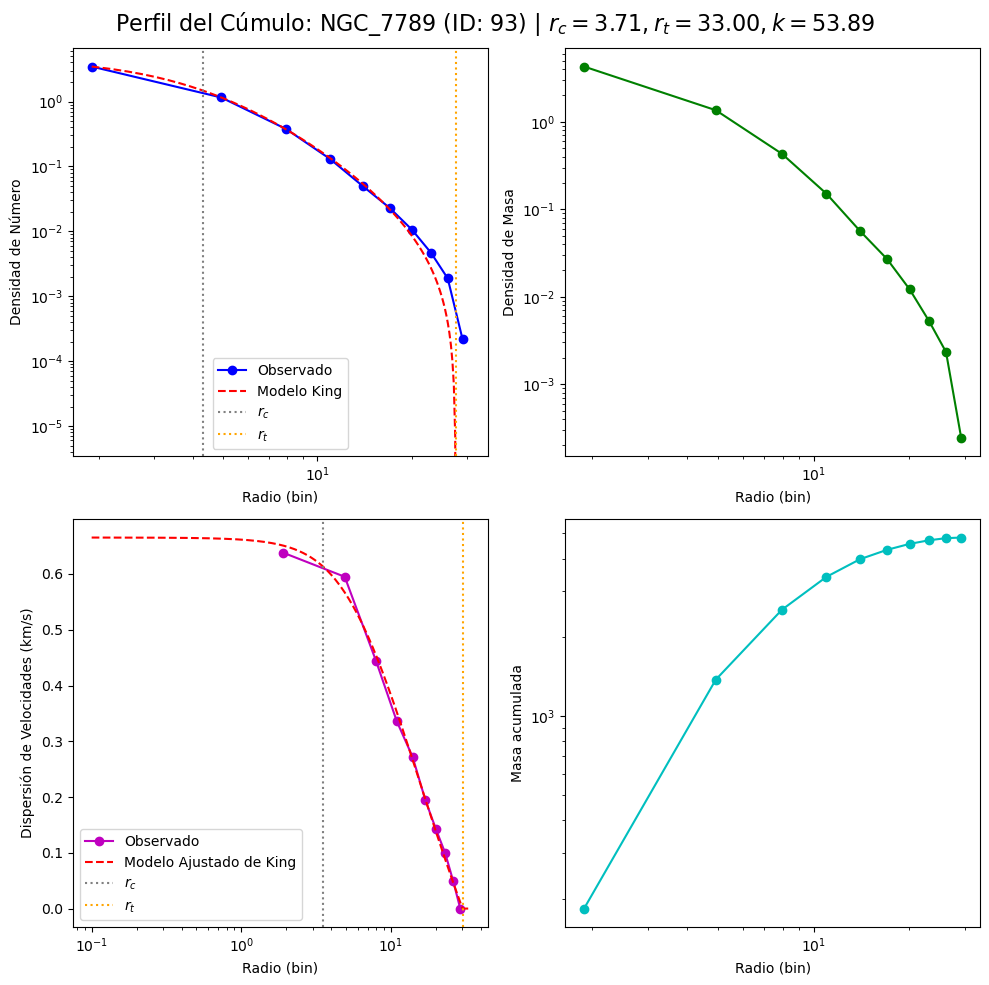

In [31]:
plot_cluster(93)

In [32]:
interact(plot_cluster, cluster_id=(0, 101, 1))

interactive(children=(IntSlider(value=50, description='cluster_id', max=101), Output()), _dom_classes=('widget…

<function __main__.plot_cluster(cluster_id)>